# Qwen3-VL-Embedding-8B でメッセージのembeddingを生成

このノートブックでは、traQのメッセージからテキストと画像を抽出し、Qwen3-VL-Embedding-8Bモデルでembeddingを生成します。


In [1]:
# 必要なパッケージのインストール
%pip install transformers accelerate torch pillow requests python-dotenv numpy scikit-learn matplotlib seaborn -q

In [2]:
import torch
import gc

# メモリをクリア
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")


PyTorch version: 2.9.0+cu126
CUDA available: True
CUDA device: NVIDIA A100-SXM4-80GB
GPU Memory: 79.32 GB


In [3]:
# messages.pyのコードを定義
from typing import Iterable, Optional
import requests
import os

messageIds = [
    "019b2a64-eebc-7815-84c5-e384fabc495c", #ictトラブルシューティング予選結果
    "019a48ff-b175-783c-93fc-b4ec6731dde5", #TechBookの販売記録
    "019bb6b8-5c57-7d1f-8b93-297c8e6c7827", #ポータブルモニターを購入
    "019bb5c0-5409-7b3b-ba9b-07449030364a", #大学の課題の締め切り
    "019bd043-d86c-79b8-9cf1-11351a482267", #pcの空き容量の画像
    "0197c4ef-8be2-792e-922b-c498b6948775", #traqの9点リーダーのアイコン
    "01963951-0f55-75b5-a53b-07f467ad9051", #sysad体験会
    "0195be37-dea6-7902-8d04-e46185873108", #githubへの招待
    "019bde55-0ca0-7d7a-95ab-0a1c3bf5eeaa", #僕のgithub
    "019bde55-b166-7d7b-b290-2f049f72fe08" #googleの検索画面
]

def _get_session() -> requests.Session:
    r_session = os.getenv("r_session")
    if not r_session:
        raise RuntimeError("r_session が見つかりません（環境変数を設定してください）")
    
    session = requests.Session()
    session.cookies.set("r_session", r_session)
    return session

def get_messages(target_message_ids: Optional[Iterable[str]] = None):
    base_url = "https://q.trap.jp/api/v3"
    ids = list(target_message_ids) if target_message_ids is not None else messageIds
    
    result = []
    
    with _get_session() as session:
        for message_id in ids:
            url = f"{base_url}/messages/{message_id}"
            
            try:
                response = session.get(url)
                response.raise_for_status()
                result.append(response.json())
            except requests.exceptions.RequestException as e:
                print(f"Error fetching message {message_id}: {e}")
    
    return result

def download_file(file_id: str, base_url: str = "https://q.trap.jp/api/v3") -> bytes:
    with _get_session() as session:
        url = f"{base_url}/files/{file_id}"
        response = session.get(url)
        response.raise_for_status()
        return response.content

print("messages.pyの関数を定義しました")


messages.pyの関数を定義しました


In [4]:
# traQ APIのセッション情報を設定
# Colabのシークレット機能を使うか、直接設定してください
import os

# 方法1: 直接設定（セキュリティ上推奨されませんが、テスト用）
# os.environ["r_session"] = "your_session_token_here"

# 方法2: Colabのシークレットを使う場合（推奨）
# from google.colab import userdata
# os.environ["r_session"] = userdata.get('r_session')

# 方法3: 入力で設定
r_session = input("r_sessionを入力してください: ").strip()
if r_session:
    os.environ["r_session"] = r_session
    print("r_sessionを設定しました")
else:
    print("警告: r_sessionが設定されていません")


r_sessionを設定しました


In [5]:
# main.pyのコードを定義
import base64
import io
import json
import re
from typing import Any, Dict, List, Optional, Tuple

from PIL import Image
import torch
import torch.nn.functional as F
from transformers import AutoModel, AutoProcessor

MODEL_NAME = "Qwen/Qwen3-VL-Embedding-8B"
BASE_URL = "https://q.trap.jp/api/v3"

def last_token_pool(
    last_hidden_states: torch.Tensor,
    attention_mask: torch.Tensor,
) -> torch.Tensor:
    """Qwen3-Embeddingで推奨される最後のトークンのhidden stateを取得"""
    left_padding = attention_mask[:, -1].sum() == attention_mask.shape[0]
    if left_padding:
        return last_hidden_states[:, -1]
    else:
        sequence_lengths = attention_mask.sum(dim=1) - 1
        batch_size = last_hidden_states.shape[0]
        return last_hidden_states[
            torch.arange(batch_size, device=last_hidden_states.device),
            sequence_lengths,
        ]

def extract_text(message: Dict[str, Any]) -> str:
    for key in ("content", "text", "body", "message"):
        value = message.get(key)
        if isinstance(value, str) and value.strip():
            return value
    return ""

def extract_image_file_ids(message: Dict[str, Any]) -> List[str]:
    file_ids: List[str] = []
    
    files = message.get("files")
    if isinstance(files, list):
        for item in files:
            if not isinstance(item, dict):
                continue
            file_id = item.get("id") or item.get("fileId")
            mime = item.get("mime") or item.get("mimeType") or item.get("type")
            if file_id and isinstance(mime, str) and mime.startswith("image/"):
                file_ids.append(file_id)
    
    content = extract_text(message)
    if content:
        patterns = [
            r"/files/([0-9a-fA-F-]{16,})",
            r"https?://q\.trap\.jp/[^\s]*/files/([0-9a-fA-F-]{16,})",
            r"https?://q\.trap\.jp/api/v3/files/([0-9a-fA-F-]{16,})",
        ]
        for pattern in patterns:
            for match in re.findall(pattern, content):
                file_ids.append(match)
    
    return list(dict.fromkeys(file_ids))

def extract_inline_images(message: Dict[str, Any]) -> List[Image.Image]:
    images: List[Image.Image] = []
    
    inline = message.get("images") or message.get("image")
    if isinstance(inline, list):
        candidates = inline
    else:
        candidates = [inline] if inline is not None else []
    
    for item in candidates:
        if isinstance(item, dict):
            data = item.get("data") or item.get("base64")
        elif isinstance(item, str):
            data = item
        else:
            data = None
        
        if not isinstance(data, str):
            continue
        
        if data.startswith("data:image"):
            try:
                header, b64 = data.split(",", 1)
                image_bytes = io.BytesIO(base64.b64decode(b64))
                images.append(Image.open(image_bytes).convert("RGB"))
            except Exception:
                continue
    
    return images

def load_images_from_message(message: Dict[str, Any]) -> List[Image.Image]:
    images: List[Image.Image] = []
    images.extend(extract_inline_images(message))
    
    for file_id in extract_image_file_ids(message):
        try:
            content = download_file(file_id, base_url=BASE_URL)
            images.append(Image.open(io.BytesIO(content)).convert("RGB"))
        except Exception as exc:
            print(f"画像の取得に失敗: {file_id} -> {exc}")
    
    return images

print("main.pyの関数を定義しました")


main.pyの関数を定義しました


In [6]:
# メモリ最適化版のload_model関数
def load_model():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    dtype = torch.float16 if device == "cuda" else torch.float32
    
    print(f"デバイス: {device}, dtype: {dtype}")
    
    # GPUメモリ情報を表示
    if device == "cuda":
        print(f"利用可能なGPUメモリ: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
        print(f"現在の使用メモリ: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")
    
    print(f"モデルをロード中: {MODEL_NAME}")
    
    # Qwen3-VL-Embedding-8Bのロード（メモリ最適化版）
    model = AutoModel.from_pretrained(
        MODEL_NAME,
        trust_remote_code=True,
        torch_dtype=dtype,
        device_map="auto" if device == "cuda" else None,
        low_cpu_mem_usage=True,  # CPUメモリ使用量を削減
    )
    processor = AutoProcessor.from_pretrained(
        MODEL_NAME,
        trust_remote_code=True,
    )
    model.eval()
    
    # 推論モードで勾配計算を無効化（メモリ節約）
    for param in model.parameters():
        param.requires_grad = False
    
    if device == "cpu":
        model.to(device)
    
    print("モデルのロード完了")
    if device == "cuda":
        print(f"ロード後の使用メモリ: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")
    
    return model, processor, device


In [7]:
# encode_batch関数（メモリ最適化版）
def encode_batch(
    model,
    processor,
    texts: List[str],
    images: Optional[List[Image.Image]],
    device: str,
) -> torch.Tensor:
    """
    テキストと画像をembeddingに変換する。
    Qwen3-Embeddingでは最後のトークンのhidden stateを使用（last token pooling）。
    """
    # モデルに組み込みのencodeメソッドがあれば使用
    if hasattr(model, "get_embedding"):
        try:
            return model.get_embedding(text=texts, images=images)
        except Exception as e:
            print(f"get_embeddingメソッドでエラー: {e}")
    
    # 画像がある場合の処理
    if images:
        processed_texts = []
        for text in texts:
            if "<image>" not in text and "<|image|>" not in text:
                processed_texts.append(f"<|vision_start|><|image_pad|><|vision_end|>{text}")
            else:
                processed_texts.append(text)
        
        inputs = processor(
            text=processed_texts,
            images=images,
            return_tensors="pt",
            padding=True,
        )
    else:
        inputs = processor(
            text=texts,
            return_tensors="pt",
            padding=True,
        )
    
    # デバイスに移動
    inputs = {k: v.to(device) if hasattr(v, "to") else v for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    # Qwen3-Embedding標準: last token pooling
    if hasattr(outputs, "last_hidden_state"):
        hidden_states = outputs.last_hidden_state
        attention_mask = inputs.get("attention_mask")
        
        if attention_mask is not None:
            embeddings = last_token_pool(hidden_states, attention_mask)
        else:
            embeddings = hidden_states[:, -1]
        
        # L2正規化
        embeddings = F.normalize(embeddings, p=2, dim=1)
        
        # メモリ節約: 不要なテンソルを削除
        del hidden_states, outputs
        if device == "cuda":
            torch.cuda.empty_cache()
        
        return embeddings
    
    # フォールバック
    if hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
        result = F.normalize(outputs.pooler_output, p=2, dim=1)
        del outputs
        if device == "cuda":
            torch.cuda.empty_cache()
        return result
    
    result = F.normalize(outputs[0][:, -1], p=2, dim=1)
    del outputs
    if device == "cuda":
        torch.cuda.empty_cache()
    return result


メッセージを取得中...
取得したメッセージ数: 10

メッセージ 1: 019b2a64-eebc-7815-84c5-e384fabc495c
テキスト: :tada: 味処まるたかエグい
https://icttoracon.net/archives/10329
https://q.trap.jp/files/019b2a64-ee12-7815-9d...
画像ファイルID: 1個
インライン画像: 0個

  画像 1 (file_id: 019b2a64-ee12-7815-9d3c-4c510250218a) を取得中...
  ✓ 画像を取得しました: (901, 811)

メッセージ 2: 019a48ff-b175-783c-93fc-b4ec6731dde5
テキスト: TechBookの販売記録です

https://q.trap.jp/files/019a48ff-affe-783c-bda0-337d95b05124
画像ファイルID: 1個
インライン画像: 0個

  画像 1 (file_id: 019a48ff-affe-783c-bda0-337d95b05124) を取得中...
  ✓ 画像を取得しました: (1200, 1600)

メッセージ 3: 019bb6b8-5c57-7d1f-8b93-297c8e6c7827
テキスト: ポータブルモニターを購入して、部室に置きました
https://q.trap.jp/files/019bb6b8-531f-7d1f-bd68-be23815eadc8
https://q.trap....
画像ファイルID: 2個
インライン画像: 0個

  画像 1 (file_id: 019bb6b8-531f-7d1f-bd68-be23815eadc8) を取得中...
  ✓ 画像を取得しました: (2133, 1600)

  画像 2 (file_id: 019bb6b8-5a8a-7d1f-a0d7-e8dfd1e1b4eb) を取得中...
  ✓ 画像を取得しました: (2133, 1600)

メッセージ 4: 019bb5c0-5409-7b3b-ba9b-07449030364a
テキスト: ん

https://q.trap.jp/files/019bb5

/tmp/ipython-input-2877081050.py:94: UserWarning: Glyph 21619 (\N{CJK UNIFIED IDEOGRAPH-5473}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2877081050.py:94: UserWarning: Glyph 20966 (\N{CJK UNIFIED IDEOGRAPH-51E6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2877081050.py:94: UserWarning: Glyph 12414 (\N{HIRAGANA LETTER MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2877081050.py:94: UserWarning: Glyph 12427 (\N{HIRAGANA LETTER RU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2877081050.py:94: UserWarning: Glyph 12383 (\N{HIRAGANA LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2877081050.py:94: UserWarning: Glyph 12363 (\N{HIRAGANA LETTER KA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2877081050.py:94: UserWarning: Glyph 12456 (\N{KATAKANA LETTER E}) missing from font(s) DejaVu Sans.
  plt.tight_

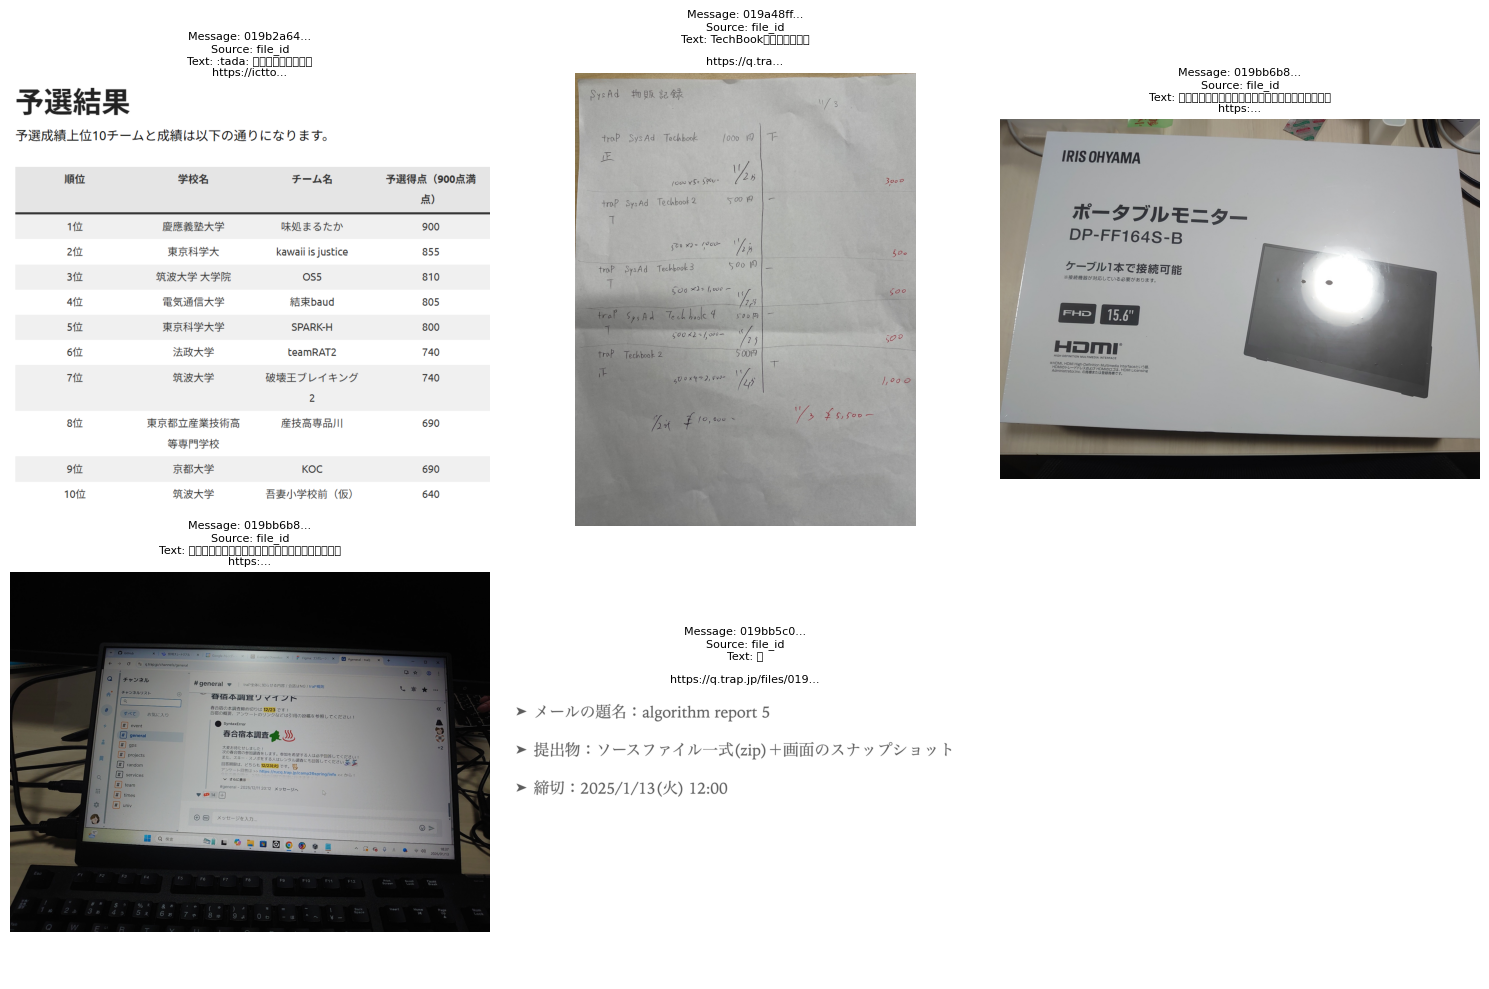


✓ 画像取得テスト完了: 5枚の画像を表示しました


In [8]:
# traQ APIから画像を取得して表示するテスト
from IPython.display import display, Image as IPythonImage
import matplotlib.pyplot as plt

# メッセージを取得
print("メッセージを取得中...")
test_messages = get_messages()
print(f"取得したメッセージ数: {len(test_messages)}")

# 画像を含むメッセージを探す
images_found = []
for i, message in enumerate(test_messages):
    message_id = message.get("id") or message.get("messageId") or "unknown"
    text = extract_text(message)
    
    # 画像ファイルIDを取得
    image_file_ids = extract_image_file_ids(message)
    
    # インライン画像を取得
    inline_images = extract_inline_images(message)
    
    if image_file_ids or inline_images:
        print(f"\nメッセージ {i+1}: {message_id}")
        print(f"テキスト: {text[:100]}..." if len(text) > 100 else f"テキスト: {text}")
        print(f"画像ファイルID: {len(image_file_ids)}個")
        print(f"インライン画像: {len(inline_images)}個")
        
        # ファイルIDから画像を取得して表示
        for j, file_id in enumerate(image_file_ids[:3]):  # 最大3枚まで
            try:
                print(f"\n  画像 {j+1} (file_id: {file_id}) を取得中...")
                image_bytes = download_file(file_id, base_url=BASE_URL)
                img = Image.open(io.BytesIO(image_bytes)).convert("RGB")
                images_found.append({
                    'message_id': message_id,
                    'text': text,
                    'image': img,
                    'source': 'file_id'
                })
                print(f"  ✓ 画像を取得しました: {img.size}")
            except Exception as e:
                print(f"  ✗ 画像の取得に失敗: {e}")
        
        # インライン画像を表示
        for j, img in enumerate(inline_images[:3]):  # 最大3枚まで
            images_found.append({
                'message_id': message_id,
                'text': text,
                'image': img,
                'source': 'inline'
            })
            print(f"  ✓ インライン画像 {j+1}: {img.size}")
        
        # 最大5枚まで表示
        if len(images_found) >= 5:
            break

# 画像を表示
if images_found:
    print(f"\n\n=== 取得した画像を表示します ({len(images_found)}枚) ===")
    
    # グリッド表示用に設定
    num_images = len(images_found)
    cols = min(3, num_images)
    rows = (num_images + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    if rows == 1:
        axes = axes.reshape(1, -1) if num_images > 1 else [axes]
    elif cols == 1:
        axes = axes.reshape(-1, 1)
    
    for idx, img_data in enumerate(images_found):
        row = idx // cols
        col = idx % cols
        
        ax = axes[row, col] if rows > 1 else axes[col]
        ax.imshow(img_data['image'])
        ax.axis('off')
        ax.set_title(
            f"Message: {img_data['message_id'][:8]}...\n"
            f"Source: {img_data['source']}\n"
            f"Text: {img_data['text'][:30]}..." if len(img_data['text']) > 30 else f"Text: {img_data['text']}",
            fontsize=8
        )
    
    # 余った軸を非表示
    for idx in range(num_images, rows * cols):
        row = idx // cols
        col = idx % cols
        ax = axes[row, col] if rows > 1 else axes[col]
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ 画像取得テスト完了: {len(images_found)}枚の画像を表示しました")
else:
    print("\n⚠ 画像を含むメッセージが見つかりませんでした。")
    print("メッセージの内容を確認:")
    for i, message in enumerate(test_messages[:3]):
        print(f"\nメッセージ {i+1}:")
        print(f"  ID: {message.get('id') or message.get('messageId')}")
        print(f"  テキスト: {extract_text(message)[:100]}")
        print(f"  ファイル: {message.get('files', [])}")


In [9]:
# embed_message関数
def embed_message(
    model,
    processor,
    message: Dict[str, Any],
    device: str,
) -> Tuple[List[float], int]:
    text = extract_text(message)
    images = load_images_from_message(message)
    
    if images:
        texts = [text] * len(images)
        emb = encode_batch(model, processor, texts, images, device)
        emb = emb.mean(dim=0)
    else:
        emb = encode_batch(model, processor, [text], None, device)[0]
    
    return emb.float().cpu().tolist(), len(images)


## モデルのロード

最初にモデルをロードします。これには5.5分程度かかる場合があります。


In [13]:
# モデルをロード（キャッシュ対応版）
import os
import json

# Colabのストレージパス
CACHE_DIR = "/content/models/Qwen3-VL-Embedding-8B"

def is_cache_valid(cache_dir):
    """キャッシュディレクトリが有効かどうかを確認"""
    # 必要なファイルが存在するか確認
    config_path = os.path.join(cache_dir, "config.json")
    
    if not os.path.exists(cache_dir):
        return False
    
    if not os.path.exists(config_path):
        return False
    
    try:
        with open(config_path, "r", encoding="utf-8") as f:
            config = json.load(f)
        # model_typeキーが存在するか確認
        return "model_type" in config
    except Exception:
        return False

def load_model(use_cache=True):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    dtype = torch.float16 if device == "cuda" else torch.float32
    
    print(f"デバイス: {device}, dtype: {dtype}")
    
    # GPUメモリ情報を表示
    if device == "cuda":
        print(f"利用可能なGPUメモリ: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
        print(f"現在の使用メモリ: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")
    
    # キャッシュディレクトリの確認
    use_cache_path = use_cache and is_cache_valid(CACHE_DIR)
    
    if use_cache_path:
        print(f"キャッシュからモデルを読み込み中: {CACHE_DIR}")
        model_path = CACHE_DIR
        processor_path = CACHE_DIR
    else:
        print(f"モデルをダウンロード中: {MODEL_NAME}")
        model_path = MODEL_NAME
        processor_path = MODEL_NAME
    
    # Qwen3-VL-Embedding-8Bのロード（メモリ最適化版）
    model = AutoModel.from_pretrained(
        model_path,
        trust_remote_code=True,
        torch_dtype=dtype,
        device_map="auto" if device == "cuda" else None,
        low_cpu_mem_usage=True,
    )
    
    processor = AutoProcessor.from_pretrained(
        processor_path,
        trust_remote_code=True,
    )
    
    # モデルをキャッシュに保存（初回のみ）
    if use_cache and not use_cache_path:
        print(f"モデルをキャッシュに保存中: {CACHE_DIR}")
        os.makedirs(CACHE_DIR, exist_ok=True)
        model.save_pretrained(CACHE_DIR)
        processor.save_pretrained(CACHE_DIR)
        print("✓ キャッシュ保存完了")
    
    model.eval()
    
    # 推論モードで勾配計算を無効化（メモリ節約）
    for param in model.parameters():
        param.requires_grad = False
    
    print("モデルのロード完了")
    if device == "cuda":
        print(f"ロード後の使用メモリ: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")
    
    return model, processor, device

# モデルをロード
model, processor, device = load_model(use_cache=True)

デバイス: cuda, dtype: torch.float16
利用可能なGPUメモリ: 79.32 GB
現在の使用メモリ: 0.00 GB
モデルをダウンロード中: Qwen/Qwen3-VL-Embedding-8B


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Some weights of Qwen3VLModel were not initialized from the model checkpoint at Qwen/Qwen3-VL-Embedding-8B and are newly initialized: ['language_model.embed_tokens.weight', 'language_model.layers.0.input_layernorm.weight', 'language_model.layers.0.mlp.down_proj.weight', 'language_model.layers.0.mlp.gate_proj.weight', 'language_model.layers.0.mlp.up_proj.weight', 'language_model.layers.0.post_attention_layernorm.weight', 'language_model.layers.0.self_attn.k_norm.weight', 'language_model.layers.0.self_attn.k_proj.weight', 'language_model.layers.0.self_attn.o_proj.weight', 'language_model.layers.0.self_attn.q_norm.weight', 'language_model.layers.0.self_attn.q_proj.weight', 'language_model.layers.0.self_attn.v_proj.weight', 'language_model.layers.1.input_layernorm.weight', 'language_model.layers.1.mlp.down_proj.weight', 'language_model.layers.1.mlp.gate_proj.weight', 'language_model.layers.1.mlp.up_proj.weight', 'language_model.layers.1.post_attention_layernorm.weight', 'language_model.laye

モデルをキャッシュに保存中: /content/models/Qwen3-VL-Embedding-8B
✓ キャッシュ保存完了
モデルのロード完了
ロード後の使用メモリ: 15.17 GB


## メッセージの取得とembedding生成

メッセージを取得して、それぞれのembeddingを生成します。


In [14]:
# メッセージを取得
messages = get_messages()
print(f"取得したメッセージ数: {len(messages)}")


取得したメッセージ数: 10


In [15]:
# embeddingを生成
import os

os.makedirs("out", exist_ok=True)

outputs = []
for i, message in enumerate(messages):
    message_id = message.get("id") or message.get("messageId") or "unknown"
    print(f"\n[{i+1}/{len(messages)}] 処理中: {message_id}")
    
    try:
        embedding, image_count = embed_message(model, processor, message, device)
        outputs.append(
            {
                "messageId": message_id,
                "text": extract_text(message),
                "imageCount": image_count,
                "embedding": embedding,
            }
        )
        print(f"✓ 完了: 埋め込み次元={len(embedding)} 画像={image_count}")
        
        # メモリクリア（定期的に）
        if (i + 1) % 3 == 0 and device == "cuda":
            torch.cuda.empty_cache()
            
    except Exception as e:
        print(f"✗ エラー: {e}")
        import traceback
        traceback.print_exc()

print(f"\n処理完了: {len(outputs)}件のembeddingを生成しました")



[1/10] 処理中: 019b2a64-eebc-7815-84c5-e384fabc495c
✓ 完了: 埋め込み次元=4096 画像=1

[2/10] 処理中: 019a48ff-b175-783c-93fc-b4ec6731dde5
✓ 完了: 埋め込み次元=4096 画像=1

[3/10] 処理中: 019bb6b8-5c57-7d1f-8b93-297c8e6c7827
✓ 完了: 埋め込み次元=4096 画像=2

[4/10] 処理中: 019bb5c0-5409-7b3b-ba9b-07449030364a
✓ 完了: 埋め込み次元=4096 画像=1

[5/10] 処理中: 019bd043-d86c-79b8-9cf1-11351a482267
✓ 完了: 埋め込み次元=4096 画像=2

[6/10] 処理中: 0197c4ef-8be2-792e-922b-c498b6948775
✓ 完了: 埋め込み次元=4096 画像=1

[7/10] 処理中: 01963951-0f55-75b5-a53b-07f467ad9051
✓ 完了: 埋め込み次元=4096 画像=3

[8/10] 処理中: 0195be37-dea6-7902-8d04-e46185873108
✓ 完了: 埋め込み次元=4096 画像=1

[9/10] 処理中: 019bde55-0ca0-7d7a-95ab-0a1c3bf5eeaa
✓ 完了: 埋め込み次元=4096 画像=1

[10/10] 処理中: 019bde55-b166-7d7b-b290-2f049f72fe08
✓ 完了: 埋め込み次元=4096 画像=1

処理完了: 10件のembeddingを生成しました


In [16]:
# 結果を保存
with open("out/embeddings.json", "w", encoding="utf-8") as f:
    json.dump(outputs, f, ensure_ascii=False, indent=2)

print("結果を out/embeddings.json に保存しました")

# 結果のサマリーを表示
if outputs:
    print(f"\n生成されたembeddingの次元: {len(outputs[0]['embedding'])}")
    print(f"画像を含むメッセージ数: {sum(1 for o in outputs if o['imageCount'] > 0)}")


結果を out/embeddings.json に保存しました

生成されたembeddingの次元: 4096
画像を含むメッセージ数: 10


In [17]:
# クエリとの類似度検索機能
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import sys

def calculate_similarity(query_embedding, stored_embeddings):
    """クエリembeddingと保存されたembeddingの類似度を計算"""
    # numpy配列に変換
    query_vec = np.array(query_embedding).reshape(1, -1)
    stored_vecs = np.array(stored_embeddings)
    
    # 正規化を確認・再適用（念のため）
    query_norm = np.linalg.norm(query_vec, axis=1, keepdims=True)
    stored_norms = np.linalg.norm(stored_vecs, axis=1, keepdims=True)
    
    print(f"  [デバッグ] クエリベクトルのノルム: {query_norm[0, 0]:.6f}")
    print(f"  [デバッグ] 保存ベクトルのノルム範囲: min={stored_norms.min():.6f}, max={stored_norms.max():.6f}, mean={stored_norms.mean():.6f}")
    
    # 正規化（ゼロ除算を避ける）
    query_vec_normalized = query_vec / (query_norm + 1e-8)
    stored_vecs_normalized = stored_vecs / (stored_norms + 1e-8)
    
    # コサイン類似度を計算（正規化済みベクトルの内積）
    similarities = np.dot(query_vec_normalized, stored_vecs_normalized.T)[0]
    
    return similarities

def search_similar_messages(query_text, model, processor, device, stored_data, top_k=5):
    """クエリテキストに似たメッセージを検索"""
    print(f"  [ステップ1] クエリテキストをembeddingに変換中...")
    sys.stdout.flush()
    
    # encode_batch関数を使ってクエリをembeddingに変換（メッセージ生成時と同じ処理）
    query_embedding_tensor = encode_batch(model, processor, [query_text], None, device)
    query_embedding = query_embedding_tensor[0].float().cpu().tolist()
    
    print(f"  [ステップ2] クエリembedding生成完了")
    sys.stdout.flush()
    
    # デバッグ: embeddingの統計情報を表示
    query_vec_np = np.array(query_embedding)
    print(f"  [デバッグ] クエリembedding統計:")
    print(f"    - 次元数: {len(query_embedding)}")
    print(f"    - min: {query_vec_np.min():.6f}, max: {query_vec_np.max():.6f}")
    print(f"    - mean: {query_vec_np.mean():.6f}, std: {query_vec_np.std():.6f}")
    print(f"    - L2ノルム: {np.linalg.norm(query_vec_np):.6f}")
    sys.stdout.flush()
    
    # 全ての保存済みembeddingを取得
    print(f"  [ステップ3] 保存済みembeddingを読み込み中... ({len(stored_data)}件)")
    sys.stdout.flush()
    
    stored_embeddings = [item['embedding'] for item in stored_data]
    
    # デバッグ: 保存されたembeddingの統計情報を表示（最初の1つだけ）
    if stored_embeddings:
        stored_vec_np = np.array(stored_embeddings[0])
        print(f"  [デバッグ] 保存embedding統計（最初の1件）:")
        print(f"    - 次元数: {len(stored_embeddings[0])}")
        print(f"    - min: {stored_vec_np.min():.6f}, max: {stored_vec_np.max():.6f}")
        print(f"    - mean: {stored_vec_np.mean():.6f}, std: {stored_vec_np.std():.6f}")
        print(f"    - L2ノルム: {np.linalg.norm(stored_vec_np):.6f}")
        sys.stdout.flush()
    
    # 類似度を計算
    print(f"  [ステップ4] 類似度を計算中...")
    sys.stdout.flush()
    
    similarities = calculate_similarity(query_embedding, stored_embeddings)
    
    # デバッグ: 類似度の統計情報を表示
    print(f"  [デバッグ] 類似度統計:")
    print(f"    - min: {similarities.min():.6f}, max: {similarities.max():.6f}")
    print(f"    - mean: {similarities.mean():.6f}, std: {similarities.std():.6f}")
    print(f"    - 上位5件: {np.sort(similarities)[::-1][:5]}")
    sys.stdout.flush()
    
    # 類似度の高い順にソートしてインデックスを取得
    sorted_indices = np.argsort(similarities)[::-1][:top_k]
    
    # 結果を整形
    print(f"  [ステップ5] 結果を整形中...")
    sys.stdout.flush()
    
    results = []
    for rank, idx in enumerate(sorted_indices, 1):
        similarity_score = similarities[idx]
        message_data = stored_data[idx]
        
        results.append({
            'rank': rank,
            'message_id': message_data['messageId'],
            'text': message_data['text'][:100] + '...' if len(message_data['text']) > 100 else message_data['text'],
            'image_count': message_data['imageCount'],
            'similarity_score': float(similarity_score),
            'similarity_percentage': f"{similarity_score * 100:.2f}%"
        })
    
    return results, query_embedding

# インタラクティブな検索機能
def interactive_search(model, processor, device, stored_data):
    """ユーザーがクエリを入力して類似メッセージを検索"""
    print("=== Embedding 類似度検索 ===")
    print("終了するには 'quit' または 'exit' と入力してください")
    print("-" * 50)
    
    while True:
        query = input("\n検索クエリを入力してください: ").strip()
        
        if query.lower() in ['quit', 'exit', 'q']:
            print("検索を終了します。")
            break
        
        if not query:
            print("クエリが空です。もう一度入力してください。")
            continue
        
        print(f"\nクエリ: '{query}'")
        print("検索中...")
        
        try:
            results, query_embedding = search_similar_messages(
                query, model, processor, device, stored_data, top_k=5
            )
            
            print(f"\n{'='*60}")
            print(f"=== 類似度ランキング (Top {len(results)}) ===")
            print(f"{'='*60}")
            
            for result in results:
                print(f"\n[{result['rank']}] 類似度: {result['similarity_percentage']} (スコア: {result['similarity_score']:.6f})")
                print(f"    メッセージID: {result['message_id']}")
                print(f"    テキスト: {result['text']}")
                if result['image_count'] > 0:
                    print(f"    画像数: {result['image_count']}")
            
            print(f"\n{'='*60}")
            print(f"クエリembedding次元: {len(query_embedding)}")
            print(f"{'='*60}\n")
            sys.stdout.flush()
            
        except Exception as e:
            print(f"検索中にエラーが発生しました: {e}")
            import traceback
            traceback.print_exc()

# 保存されたデータを読み込み
import json
import os

if os.path.exists("out/embeddings.json"):
    with open("out/embeddings.json", "r", encoding="utf-8") as f:
        stored_data = json.load(f)
    
    print(f"保存されたembeddingデータを読み込みました: {len(stored_data)}件")
    
    # デフォルト検索クエリを実行
    default_queries = [
        "github",
        "pc",
        "モニター",
        "TechBook",
        "SysAd",
        "新入生",
        "テスト",
        "紙",
        "mumumu",
        "google",
        "googleのロゴが左上にありqwen3-vlについて検索してる"
    ]
    
    print("\n" + "="*60)
    print("=== デフォルト検索クエリの実行 ===")
    print("="*60)
    
    for query in default_queries:
        print(f"\n{'='*60}")
        print(f"クエリ: '{query}'")
        print("検索中...")
        
        try:
            results, query_embedding = search_similar_messages(
                query, model, processor, device, stored_data, top_k=3
            )
            
            print(f"\n=== 類似度ランキング (Top {len(results)}) ===")
            for result in results:
                print(f"\n[{result['rank']}] 類似度: {result['similarity_percentage']} (スコア: {result['similarity_score']:.6f})")
                print(f"    メッセージID: {result['message_id']}")
                print(f"    テキスト: {result['text']}")
                if result['image_count'] > 0:
                    print(f"    画像数: {result['image_count']}")
            
            print(f"\nクエリembedding次元: {len(query_embedding)}")
            sys.stdout.flush()
            
        except Exception as e:
            print(f"検索中にエラーが発生しました: {e}")
            import traceback
            traceback.print_exc()
    
    print("\n" + "="*60)
    print("=== デフォルト検索完了 ===")
    print("="*60)
    print("\nインタラクティブ検索を開始しますか？")
    print("開始する場合は、次のセルで interactive_search(model, processor, device, stored_data) を実行してください。")

else:
    print("out/embeddings.jsonが見つかりません。まずembedding生成を実行してください。")

保存されたembeddingデータを読み込みました: 10件

=== デフォルト検索クエリの実行 ===

クエリ: 'github'
検索中...
  [ステップ1] クエリテキストをembeddingに変換中...
  [ステップ2] クエリembedding生成完了
  [デバッグ] クエリembedding統計:
    - 次元数: 4096
    - min: -0.054657, max: 0.069458
    - mean: -0.000095, std: 0.015625
    - L2ノルム: 0.999993
  [ステップ3] 保存済みembeddingを読み込み中... (10件)
  [デバッグ] 保存embedding統計（最初の1件）:
    - 次元数: 4096
    - min: -0.058167, max: 0.054260
    - mean: 0.000007, std: 0.015625
    - L2ノルム: 0.999994
  [ステップ4] 類似度を計算中...
  [デバッグ] クエリベクトルのノルム: 0.999993
  [デバッグ] 保存ベクトルのノルム範囲: min=0.711345, max=1.000010, mean=0.931448
  [デバッグ] 類似度統計:
    - min: -0.023687, max: 0.022273
    - mean: -0.002711, std: 0.014329
    - 上位5件: [ 0.02227342  0.01876825  0.01080106 -0.00516439 -0.00551882]
  [ステップ5] 結果を整形中...

=== 類似度ランキング (Top 3) ===

[1] 類似度: 2.23% (スコア: 0.022273)
    メッセージID: 019b2a64-eebc-7815-84c5-e384fabc495c
    テキスト: :tada: 味処まるたかエグい
https://icttoracon.net/archives/10329
https://q.trap.jp/files/019b2a64-ee12-7815-9d...
    画像数: 1

[2] 類似度: 1.8

## インタラクティブ検索（オプション）

デフォルト検索の後、カスタムクエリで検索したい場合はこのセルを実行してください。


In [ ]:
# インタラクティブ検索を開始（オプション）
# このセルを実行すると、カスタムクエリで検索できます

# if 'stored_data' in locals() and 'model' in locals():
#     print("インタラクティブ検索を開始します...")
#     interactive_search(model, processor, device, stored_data)
# else:
#     print("エラー: まず前のセルでembeddingデータを読み込んでください。")


## 画像同士の類似度マトリックス

各メッセージの画像embedding同士の類似度を8x8のマトリックス（ヒートマップ）で可視化します。


読み込んだメッセージ数: 10件
(Ximg)の意味: そのメッセージに含まれる画像の数

Embedding配列の形状: (10, 4096)
各embeddingのノルム: [np.float64(0.9999939173003132), np.float64(1.0000025566690385), np.float64(0.7295245427516677)]

類似度マトリックスを計算中...
類似度マトリックスの形状: (10, 10)
類似度の範囲: min=0.0058, max=1.0000
対角成分（自己類似度）: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


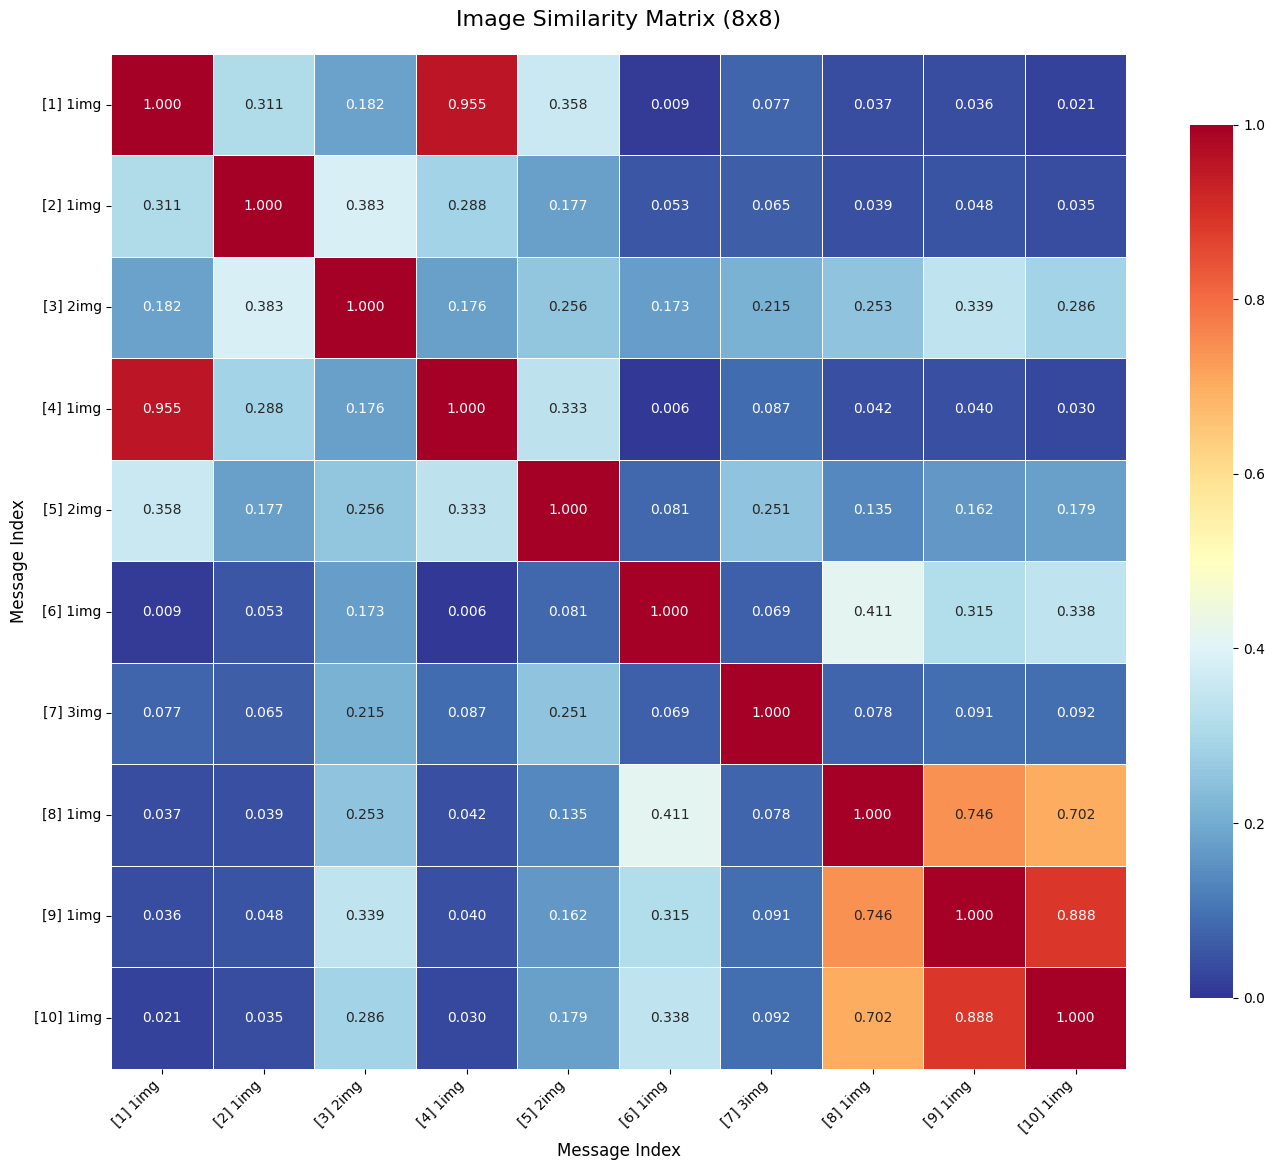


=== 類似度マトリックスの統計情報 ===
平均類似度: 0.2970
標準偏差: 0.3160
最大類似度（自己以外）: 0.9551
最小類似度: 0.0058

=== 最も類似度が高いペア（上位5組） ===

[1] 類似度: 0.9551
  メッセージ1: 019bb5c0... - ん

https://q.trap.jp/files/019bb5c0-533d-7b3b-aced-1ecb938509d2
  メッセージ2: 019b2a64... - :tada: 味処まるたかエグい
https://icttoracon.net/archives/10329
https://q.trap.jp/files/019b2a64-ee12-7815-9d3c-4c510250218a

[2] 類似度: 0.9551
  メッセージ1: 019b2a64... - :tada: 味処まるたかエグい
https://icttoracon.net/archives/10329
https://q.trap.jp/files/019b2a64-ee12-7815-9d3c-4c510250218a
  メッセージ2: 019bb5c0... - ん

https://q.trap.jp/files/019bb5c0-533d-7b3b-aced-1ecb938509d2

[3] 類似度: 0.8883
  メッセージ1: 019bde55... - 検索

https://q.trap.jp/files/019bde55-b081-7d7b-acbe-ff0013434eb3
  メッセージ2: 019bde55... - readme

https://q.trap.jp/files/019bde55-0b9c-7d7a-ba6a-cfff6ed3be30

[4] 類似度: 0.8883
  メッセージ1: 019bde55... - readme

https://q.trap.jp/files/019bde55-0b9c-7d7a-ba6a-cfff6ed3be30
  メッセージ2: 019bde55... - 検索

https://q.trap.jp/files/019bde55-b081-7d7b-acbe-ff0013434eb3



In [ ]:
# 画像同士の類似度マトリックス（8x8）を作成 - 画像サムネイル付き
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.patches import FancyBboxPatch

# 日本語フォントを設定（Colab対応）
# Colabでは日本語フォントをインストールする必要がある
try:
    # Colabで日本語フォントをインストール
    import subprocess
    subprocess.run(['apt-get', 'install', '-y', 'fonts-noto-cjk'], capture_output=True)
    matplotlib.rcParams['font.family'] = 'Noto Sans CJK JP'
except:
    pass

# フォントキャッシュをクリア
matplotlib.font_manager._load_fontmanager()

# 保存されたデータを読み込み
if os.path.exists("out/embeddings.json"):
    with open("out/embeddings.json", "r", encoding="utf-8") as f:
        stored_data = json.load(f)
    
    print(f"読み込んだメッセージ数: {len(stored_data)}件")
    print(f"(Ximg)の意味: そのメッセージに含まれる画像の数")
    
    # 全てのembeddingを取得
    embeddings = [item['embedding'] for item in stored_data]
    embeddings_array = np.array(embeddings)
    
    print(f"\nEmbedding配列の形状: {embeddings_array.shape}")
    print(f"各embeddingのノルム: {[np.linalg.norm(emb) for emb in embeddings[:3]]}")
    
    # 類似度マトリックスを計算
    print("\n類似度マトリックスを計算中...")
    similarity_matrix = cosine_similarity(embeddings_array)
    
    print(f"類似度マトリックスの形状: {similarity_matrix.shape}")
    print(f"類似度の範囲: min={similarity_matrix.min():.4f}, max={similarity_matrix.max():.4f}")
    print(f"対角成分（自己類似度）: {np.diag(similarity_matrix)}")
    
    # 画像を読み込む
    print("\n画像を読み込み中...")
    thumbnails = []
    for i, item in enumerate(stored_data):
        msg_id = item['messageId']
        try:
            messages = get_messages([msg_id])
            if messages:
                message = messages[0]
                images = load_images_from_message(message)
                if images:
                    # サムネイルサイズにリサイズ
                    img = images[0]
                    img.thumbnail((100, 100))
                    thumbnails.append(img)
                    print(f"  [{i+1}] 画像を読み込みました: {img.size}")
                else:
                    thumbnails.append(None)
                    print(f"  [{i+1}] 画像が見つかりません")
            else:
                thumbnails.append(None)
                print(f"  [{i+1}] メッセージが見つかりません")
        except Exception as e:
            thumbnails.append(None)
            print(f"  [{i+1}] エラー: {e}")
    
    # メッセージのラベルを作成（IDの短縮版）
    labels = []
    for i, item in enumerate(stored_data):
        msg_id = item['messageId'][:8]
        img_count = item['imageCount']
        # シンプルなラベル（インデックス + 画像数）
        label = f"[{i+1}] {img_count}img"
        labels.append(label)
    
    # 方法1: 画像一覧を別に表示（テーブル形式）
    print("\n=== 方法1: 画像一覧テーブル ===")
    num_images = len(thumbnails)
    cols = min(5, num_images)
    rows = (num_images + cols - 1) // cols
    
    fig1, axes1 = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    if rows == 1 and cols == 1:
        axes1 = np.array([[axes1]])
    elif rows == 1:
        axes1 = axes1.reshape(1, -1)
    elif cols == 1:
        axes1 = axes1.reshape(-1, 1)
    
    for i in range(num_images):
        row = i // cols
        col = i % cols
        ax = axes1[row, col]
        
        if thumbnails[i] is not None:
            ax.imshow(thumbnails[i])
            ax.set_title(f"[{i+1}] {stored_data[i]['imageCount']}img", fontsize=10)
        else:
            ax.text(0.5, 0.5, f"[{i+1}]\nNo Image", 
                   ha='center', va='center', fontsize=10)
        ax.axis('off')
    
    # 余った軸を非表示
    for i in range(num_images, rows * cols):
        row = i // cols
        col = i % cols
        axes1[row, col].axis('off')
    
    plt.suptitle('Image Thumbnails Reference', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    
    # 方法2: ヒートマップ単体（数値がよく見える）
    print("\n=== 方法2: 類似度ヒートマップ ===")
    fig2, ax2 = plt.subplots(figsize=(14, 12))
    
    sns.heatmap(
        similarity_matrix,
        annot=True,
        fmt='.3f',
        cmap='RdYlBu_r',  # 赤-黄-青（反転）: 高い値が赤、低い値が青
        center=0.5,
        vmin=0,
        vmax=1,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8},
        xticklabels=labels,
        yticklabels=labels,
        mask=None,  # マスクなし（全て表示）
        ax=ax2
    )
    
    ax2.set_title('Image Similarity Matrix', fontsize=16, pad=20)
    ax2.set_xlabel('Message Index', fontsize=12)
    ax2.set_ylabel('Message Index', fontsize=12)
    ax2.set_xticklabels(labels, rotation=45, ha='right')
    ax2.set_yticklabels(labels, rotation=0)
    
    plt.tight_layout()
    plt.show()
    
    # 統計情報を表示
    print("\n=== 類似度マトリックスの統計情報 ===")
    print(f"平均類似度: {similarity_matrix.mean():.4f}")
    print(f"標準偏差: {similarity_matrix.std():.4f}")
    print(f"最大類似度（自己以外）: {np.max(similarity_matrix - np.eye(len(similarity_matrix)) * similarity_matrix.max()):.4f}")
    print(f"最小類似度: {similarity_matrix.min():.4f}")
    
    # 最も類似度が高いペアを表示（自己類似度を除く）
    # 対角成分をマスク
    masked_matrix = similarity_matrix.copy()
    np.fill_diagonal(masked_matrix, -1)  # 対角成分を-1に設定
    
    # 上位5ペアを表示
    print("\n=== 最も類似度が高いペア（上位5組） ===")
    flat_indices = np.argsort(masked_matrix.flatten())[::-1][:5]
    for i, flat_idx in enumerate(flat_indices, 1):
        row = flat_idx // len(similarity_matrix)
        col = flat_idx % len(similarity_matrix)
        similarity = similarity_matrix[row, col]
        
        msg1 = stored_data[row]
        msg2 = stored_data[col]
        
        print(f"\n[{i}] 類似度: {similarity:.4f}")
        print(f"  メッセージ1: {msg1['messageId'][:8]}... - {msg1['text'][:80]}")
        print(f"  メッセージ2: {msg2['messageId'][:8]}... - {msg2['text'][:80]}")
    
else:
    print("out/embeddings.jsonが見つかりません。まずembedding生成を実行してください。")


=== 各メッセージの画像サムネイル ===
マトリックスの[番号]がどの画像に対応しているかを表示します

[1] 019b2a64... (1 images)
    Text: :tada: 味処まるたかエグい
https://icttoracon.net/archives/1...
    -> Image loaded successfully

[2] 019a48ff... (1 images)
    Text: TechBookの販売記録です

https://q.trap.jp/files/019a48ff-...
    -> Image loaded successfully

[3] 019bb6b8... (2 images)
    Text: ポータブルモニターを購入して、部室に置きました
https://q.trap.jp/files/01...
    -> Image loaded successfully

[4] 019bb5c0... (1 images)
    Text: ん

https://q.trap.jp/files/019bb5c0-533d-7b3b-aced...
    -> Image loaded successfully

[5] 019bd043... (2 images)
    Text: WSL占有しすぎだなぁ

https://q.trap.jp/files/019bd043-d717...
    -> Image loaded successfully

[6] 0197c4ef... (1 images)
    Text: 

ここのロゴ変えない？

https://q.trap.jp/files/0197c4ef-8b8...
    -> Image loaded successfully

[7] 01963951... (3 images)
    Text: SysAd体験会、約40人が来てくれて無事実施することができました！
mysql問題は本当にごめんな...
    -> Image loaded successfully

[8] 0195be37... (1 images)
    Text: 入れました！ありがとうございます！

https://q.trap

    -> Image loaded successfully



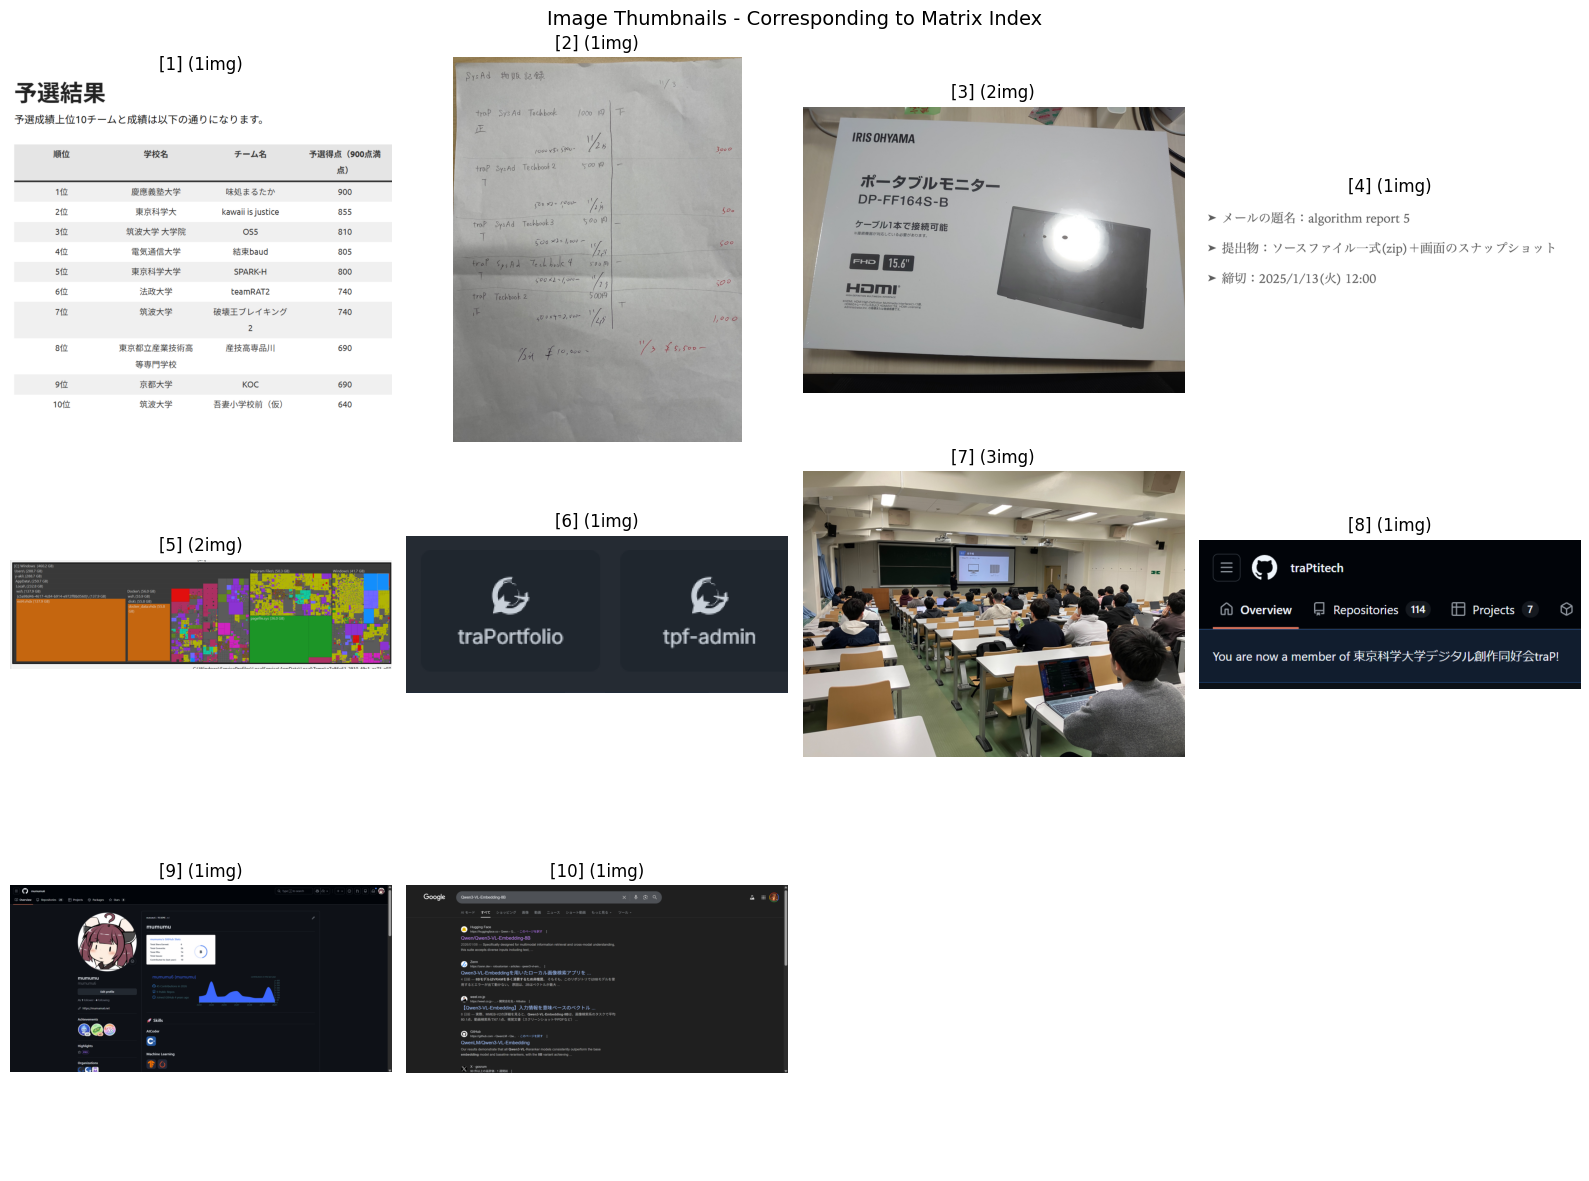


各[番号]がマトリックスの行/列に対応しています。
例: マトリックスの[1]行[5]列の値は、画像[1]と画像[5]の類似度です。


In [19]:
# 各メッセージの画像サムネイルを表示
# これにより、マトリックスの番号がどの画像に対応しているかわかる

print("=== 各メッセージの画像サムネイル ===")
print("マトリックスの[番号]がどの画像に対応しているかを表示します\n")

# 保存されたデータからメッセージIDを取得し、画像をダウンロード
thumbnails = []

for i, item in enumerate(stored_data):
    msg_id = item['messageId']
    text = item['text'][:50] + "..." if len(item['text']) > 50 else item['text']
    img_count = item['imageCount']
    
    print(f"[{i+1}] {msg_id[:8]}... ({img_count} images)")
    print(f"    Text: {text}")
    
    # メッセージを取得して画像を表示
    try:
        messages = get_messages([msg_id])
        if messages:
            message = messages[0]
            images = load_images_from_message(message)
            if images:
                thumbnails.append({
                    'index': i + 1,
                    'image': images[0],  # 最初の画像のみ
                    'text': text,
                    'img_count': img_count
                })
                print(f"    -> Image loaded successfully")
            else:
                print(f"    -> No images found in message")
        else:
            print(f"    -> Message not found")
    except Exception as e:
        print(f"    -> Error loading image: {e}")
    print()

# サムネイルグリッドを表示
if thumbnails:
    num_thumbs = len(thumbnails)
    cols = min(4, num_thumbs)
    rows = (num_thumbs + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    
    # axesを2D配列に統一
    if rows == 1 and cols == 1:
        axes = np.array([[axes]])
    elif rows == 1:
        axes = axes.reshape(1, -1)
    elif cols == 1:
        axes = axes.reshape(-1, 1)
    
    for idx, thumb in enumerate(thumbnails):
        row = idx // cols
        col = idx % cols
        ax = axes[row, col]
        
        ax.imshow(thumb['image'])
        ax.axis('off')
        ax.set_title(f"[{thumb['index']}] ({thumb['img_count']}img)", fontsize=12)
    
    # 余った軸を非表示
    for idx in range(num_thumbs, rows * cols):
        row = idx // cols
        col = idx % cols
        axes[row, col].axis('off')
    
    plt.suptitle('Image Thumbnails - Corresponding to Matrix Index', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    print("\n各[番号]がマトリックスの行/列に対応しています。")
    print("例: マトリックスの[1]行[5]列の値は、画像[1]と画像[5]の類似度です。")
else:
    print("サムネイルを取得できませんでした。")
